In [1]:
!which python

/home/gabrielecolombo/Thesis/PROJECT/.venv/bin/python


In [2]:
import os

import ase.io
import numpy as np

from sklearn.manifold import TSNE  # noqa
from sklearn.decomposition import PCA
from pprint import pprint

from openTSNE import TSNE

In [3]:
TRAINFILE = "../train/model_trani.extxyz"
VALFILE = "../val/model_val.extxyz"

train_configs = ase.io.read(TRAINFILE, index=":")
val_configs = ase.io.read(VALFILE, index=":")

In [4]:
example = train_configs[0]
print(example.info)
pprint(example.arrays['descriptors'].shape)

{'virial': array([[222.64807907,  21.56143267,  57.085707  ],
       [ 21.56143267, 247.82551997, -13.55354936],
       [ 57.085707  , -13.55354936, 156.87636104]]), 'config_type': 'Amorphous_Bulk'}
(125, 256)


In [5]:
def tsne_local_envs(configs, pca_threshold = 0.95, perplexity=50):
    """
    Perform t-SNE on local atomic environments using openTSNE.

    Args:
        configs (list): List of ASE Atoms objects

    Returns:
        descriptors_pca (np.ndarray): PCA-reduced descriptors
        tsne_results (np.ndarray): 2D t-SNE coordinates for each atom
        energies (np.ndarray): Energy per atom
        forces (np.ndarray): Forces per atom
        config_type (list): Configuration labels per atom
        pca_eigenvalues (np.ndarray): PCA eigenvalues
        pca_variance_ratio (np.ndarray): Explained variance ratio
    """

    descriptors_list = []
    energies_list = []
    forces_list = []
    config_type_list = []

    for config in configs:
        desc = config.arrays["descriptors"]
        n_atoms = desc.shape[0]

        if desc.ndim == 1:
            desc = desc.reshape(n_atoms, -1)

        descriptors_list.append(desc)
        forces_list.append(config.get_forces())
        energies_list.extend([config.get_potential_energy() / n_atoms] * n_atoms)
        config_type_list.extend([config.info["config_type"]] * n_atoms)

    descriptors_all = np.vstack(descriptors_list)
    forces_all = np.vstack(forces_list)
    energies_all = np.array(energies_list)

    # PCA
    print("[INFO] Running PCA to 50 dimensions")
    pca_model = PCA(n_components=50, svd_solver="randomized", random_state=42, n_jobs = os.cpu_count() or 1)
    descriptors_pca = pca_model.fit_transform(descriptors_all)

    # Extract eigenvalues
    pca_eigenvalues = pca_model.explained_variance_
    pca_variance_ratio = pca_model.explained_variance_ratio_

    pca_threshold_index = np.where(np.cumsum(pca_variance_ratio) >= pca_threshold)[0][0]
    print(f"[INFO] Retaining {pca_threshold_index} PCA components to explain {pca_threshold*100:.1f}% variance")
    descriptors_pca = descriptors_pca[:, :pca_threshold_index]

    pca_eigenvalues = pca_eigenvalues[:pca_threshold_index]
    pca_variance_ratio = pca_variance_ratio[:pca_threshold_index]

    # t-SNE
    print("[INFO] Running t-SNE with openTSNE")
    ncores = os.cpu_count() or 1
    tsne_model = TSNE(
        n_components=2,
        perplexity=50,
        n_iter=1000,
        initialization="pca",
        random_state=42,
        n_jobs=ncores,
        verbose=True
    )

    tsne_results = tsne_model.fit(descriptors_pca)

    return (
        descriptors_pca,
        tsne_results,
        energies_all,
        forces_all,
        config_type_list,
        pca_eigenvalues,
        pca_variance_ratio
    )

In [6]:
import numpy as np
import os
import cupy as cp
from cuml.decomposition import PCA as cumlPCA
from cuml.manifold import TSNE as cumlTSNE

def tsne_local_envs_gpu(configs, pca_threshold=0.95, perplexity=50):
    """
    GPU Accelerated t-SNE and PCA for Atomic Environments.
    Optimized for RTX 50-series (CUDA 12/13 compatible).
    """
    descriptors_list = []
    energies_list = []
    forces_list = []
    config_type_list = []

    # 1. Collection
    for config in configs:
        desc = config.arrays["descriptors"]
        n_atoms = desc.shape[0]
        if desc.ndim == 1:
            desc = desc.reshape(n_atoms, -1)
        
        descriptors_list.append(desc)
        forces_list.append(config.get_forces())
        energies_list.extend([config.get_potential_energy() / n_atoms] * n_atoms)
        config_type_list.extend([config.info["config_type"]] * n_atoms)

    # Convert to float32 for massive GPU speedup
    descriptors_all = np.vstack(descriptors_list).astype(np.float32)
    forces_all = np.vstack(forces_list)
    energies_all = np.array(energies_list)

    # 2. Transfer to Device
    print(f"[INFO] Moving {descriptors_all.shape} to GPU VRAM")
    descriptors_gpu = cp.array(descriptors_all)

    # 3. GPU PCA (Linear Acceleration)
    print("[INFO] Running cuML PCA...")
    pca_model = cumlPCA(n_components=50, svd_solver="auto")
    descriptors_pca_gpu = pca_model.fit_transform(descriptors_gpu)

    # Dynamic Thresholding on GPU
    pca_variance_ratio = pca_model.explained_variance_ratio_
    pca_threshold_index = cp.where(cp.cumsum(pca_variance_ratio) >= pca_threshold)[0][0].get()
    
    print(f"[INFO] Retaining {pca_threshold_index} components ({pca_threshold*100}%)")
    descriptors_pca_gpu = descriptors_pca_gpu[:, :pca_threshold_index]

    # 4. GPU t-SNE (Non-Linear Acceleration)
    # On an RTX 5060 Ti, this will be nearly instantaneous compared to openTSNE
    print("[INFO] Running cuML t-SNE...")
    tsne_model = cumlTSNE(
        n_components=2,
        perplexity=perplexity,
        max_iter=1000,
        random_state=42,
        learning_rate_method='adaptive', # Specific to cuML, helps convergence
        init="pca", 
        verbose=False
    )

    tsne_results_gpu = tsne_model.fit_transform(descriptors_pca_gpu)

    # 5. Bring back to CPU for ASE/Matplotlib compatibility
    return (
        descriptors_pca_gpu.get(),
        tsne_results_gpu.get(),
        energies_all,
        forces_all,
        config_type_list,
        pca_model.explained_variance_[:pca_threshold_index].get(),
        pca_variance_ratio.get()
    )

In [7]:
pca_results, tsne_results_val, energies_val, forces_val, config_type_val, pca_eigenvalues, pca_variance_ratio = tsne_local_envs_gpu(val_configs, pca_threshold=0.95, perplexity=10)

[INFO] Moving (80103, 256) to GPU VRAM
[INFO] Running cuML PCA...
[INFO] Retaining 23 components (95.0%)
[INFO] Running cuML t-SNE...


In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

def plot(results, energies, forces, config_types, target_config_types=None, i1=0, i2=1):

    if target_config_types is None:
        target_config_types = list(set(config_types))

    config_types = np.array(config_types)
    energies = np.array(energies)
    forces = np.array(forces)
    target_mask = np.isin(config_types, target_config_types)

    # Compute force modulus
    force_mod = np.linalg.norm(forces, axis=-1)
    if force_mod.ndim > 1: # Average over atoms if necessary
        force_mod = np.mean(force_mod, axis=1)

    # ----------------------------
    # 1. Plot by config_type
    # ----------------------------
    plt.figure(figsize=(8, 8))
    for config_type in target_config_types:
        mask = config_types == config_type
        plt.scatter(
            results[mask, i1],
            results[mask, i2],
            label=config_type,
            alpha=0.6,
            s=10
        )

    # plt.title("Config Type")
    plt.xlabel(f"Component {i1}")
    plt.ylabel(f"Component {i2}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("tsne_config_type.pdf")

    # ----------------------------
    # 2. Plot by energy
    # ----------------------------
    plt.figure(figsize=(8, 8))
    sc1 = plt.scatter(
        results[target_mask, i1],
        results[target_mask, i2],
        c=energies[target_mask],
        cmap="viridis",
        s=10,
        alpha=0.7
    )

    # plt.title("Energy")
    plt.xlabel(f"Component {i1}")
    plt.ylabel(f"Component {i2}")
    plt.grid(True)
    
    cbar1 = plt.colorbar(sc1)
    cbar1.set_label("Energy [eV/atom]")
    plt.tight_layout()
    plt.savefig("tsne_energy.pdf")

    # ----------------------------
    # 3. Plot by force modulus (LOG SCALE)
    # ----------------------------
    plt.figure(figsize=(8, 8))
    sc2 = plt.scatter(
        results[target_mask, i1],
        results[target_mask, i2],
        c=force_mod[target_mask],
        cmap="plasma",
        norm=LogNorm(),
        s=10,
        alpha=0.7
    )

    # plt.title("Force Magnitude (Log Scale)")
    plt.xlabel(f"Component {i1}")
    plt.ylabel(f"Component {i2}")
    plt.grid(True)
    
    cbar2 = plt.colorbar(sc2)
    cbar2.set_label(r"|F| [eV/$\AA$]")
    plt.tight_layout()
    plt.savefig("tsne_forces.pdf")

    # Display all 3 plots simultaneously
    plt.show()

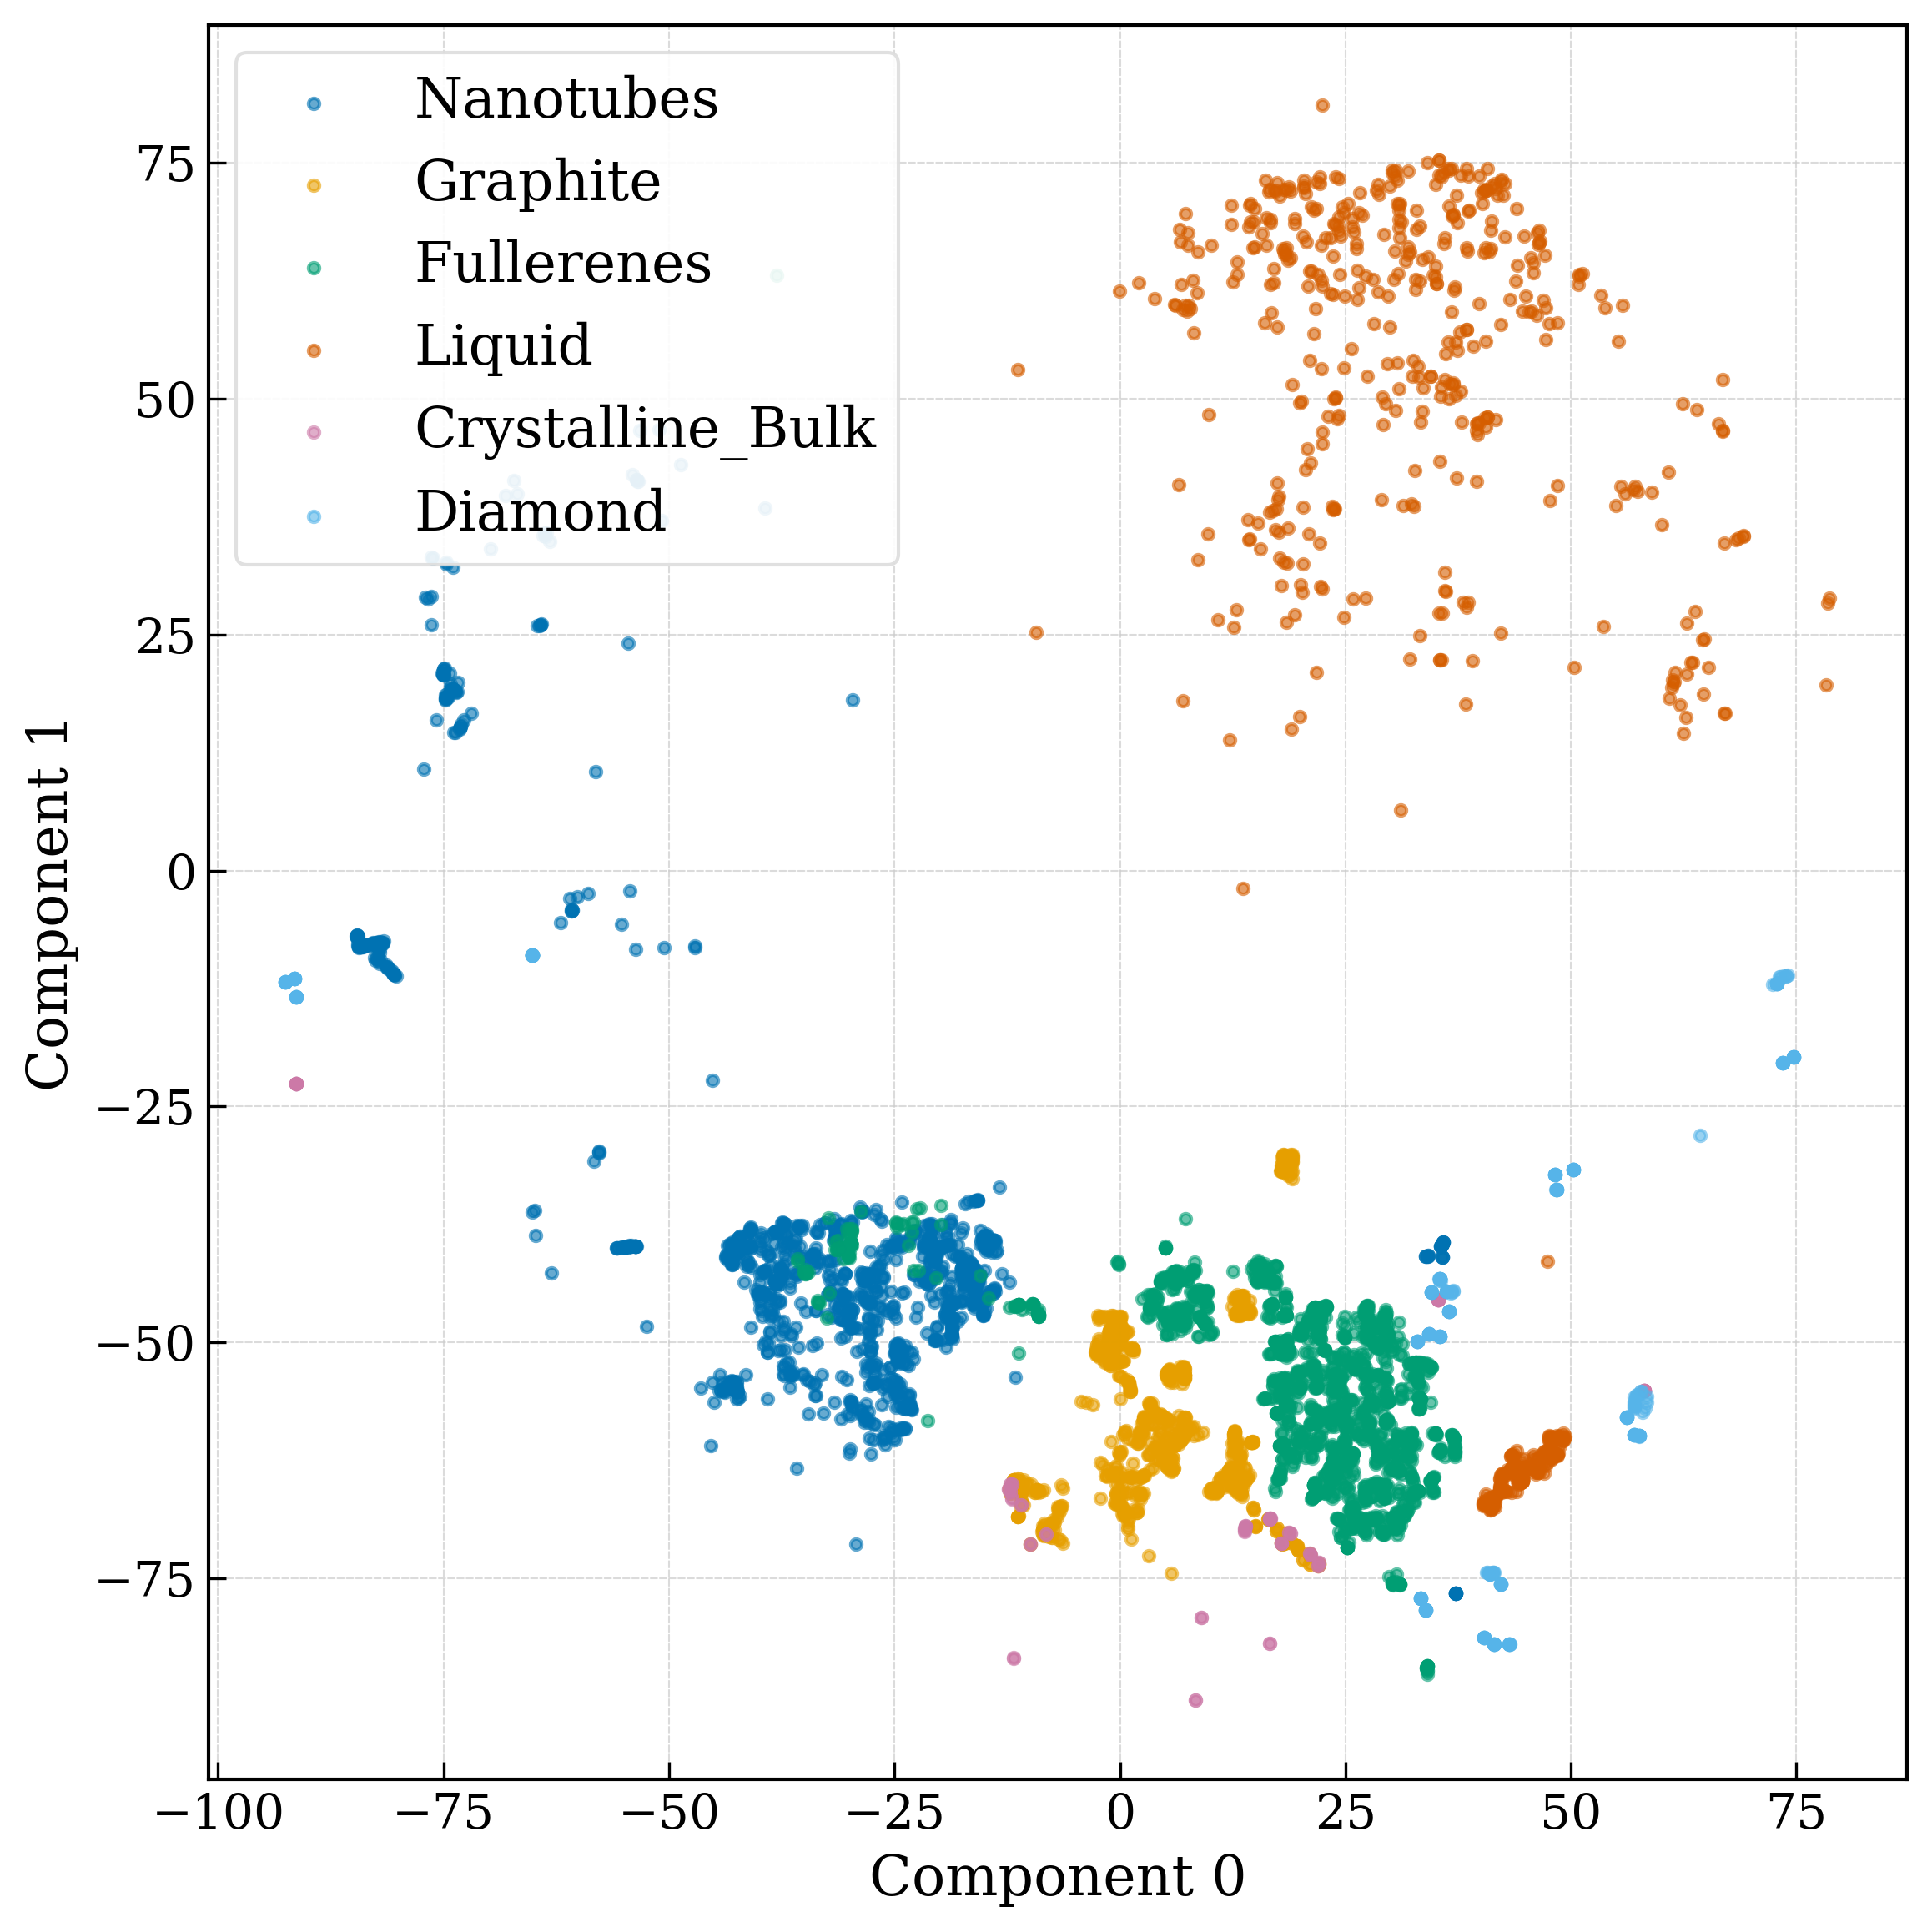

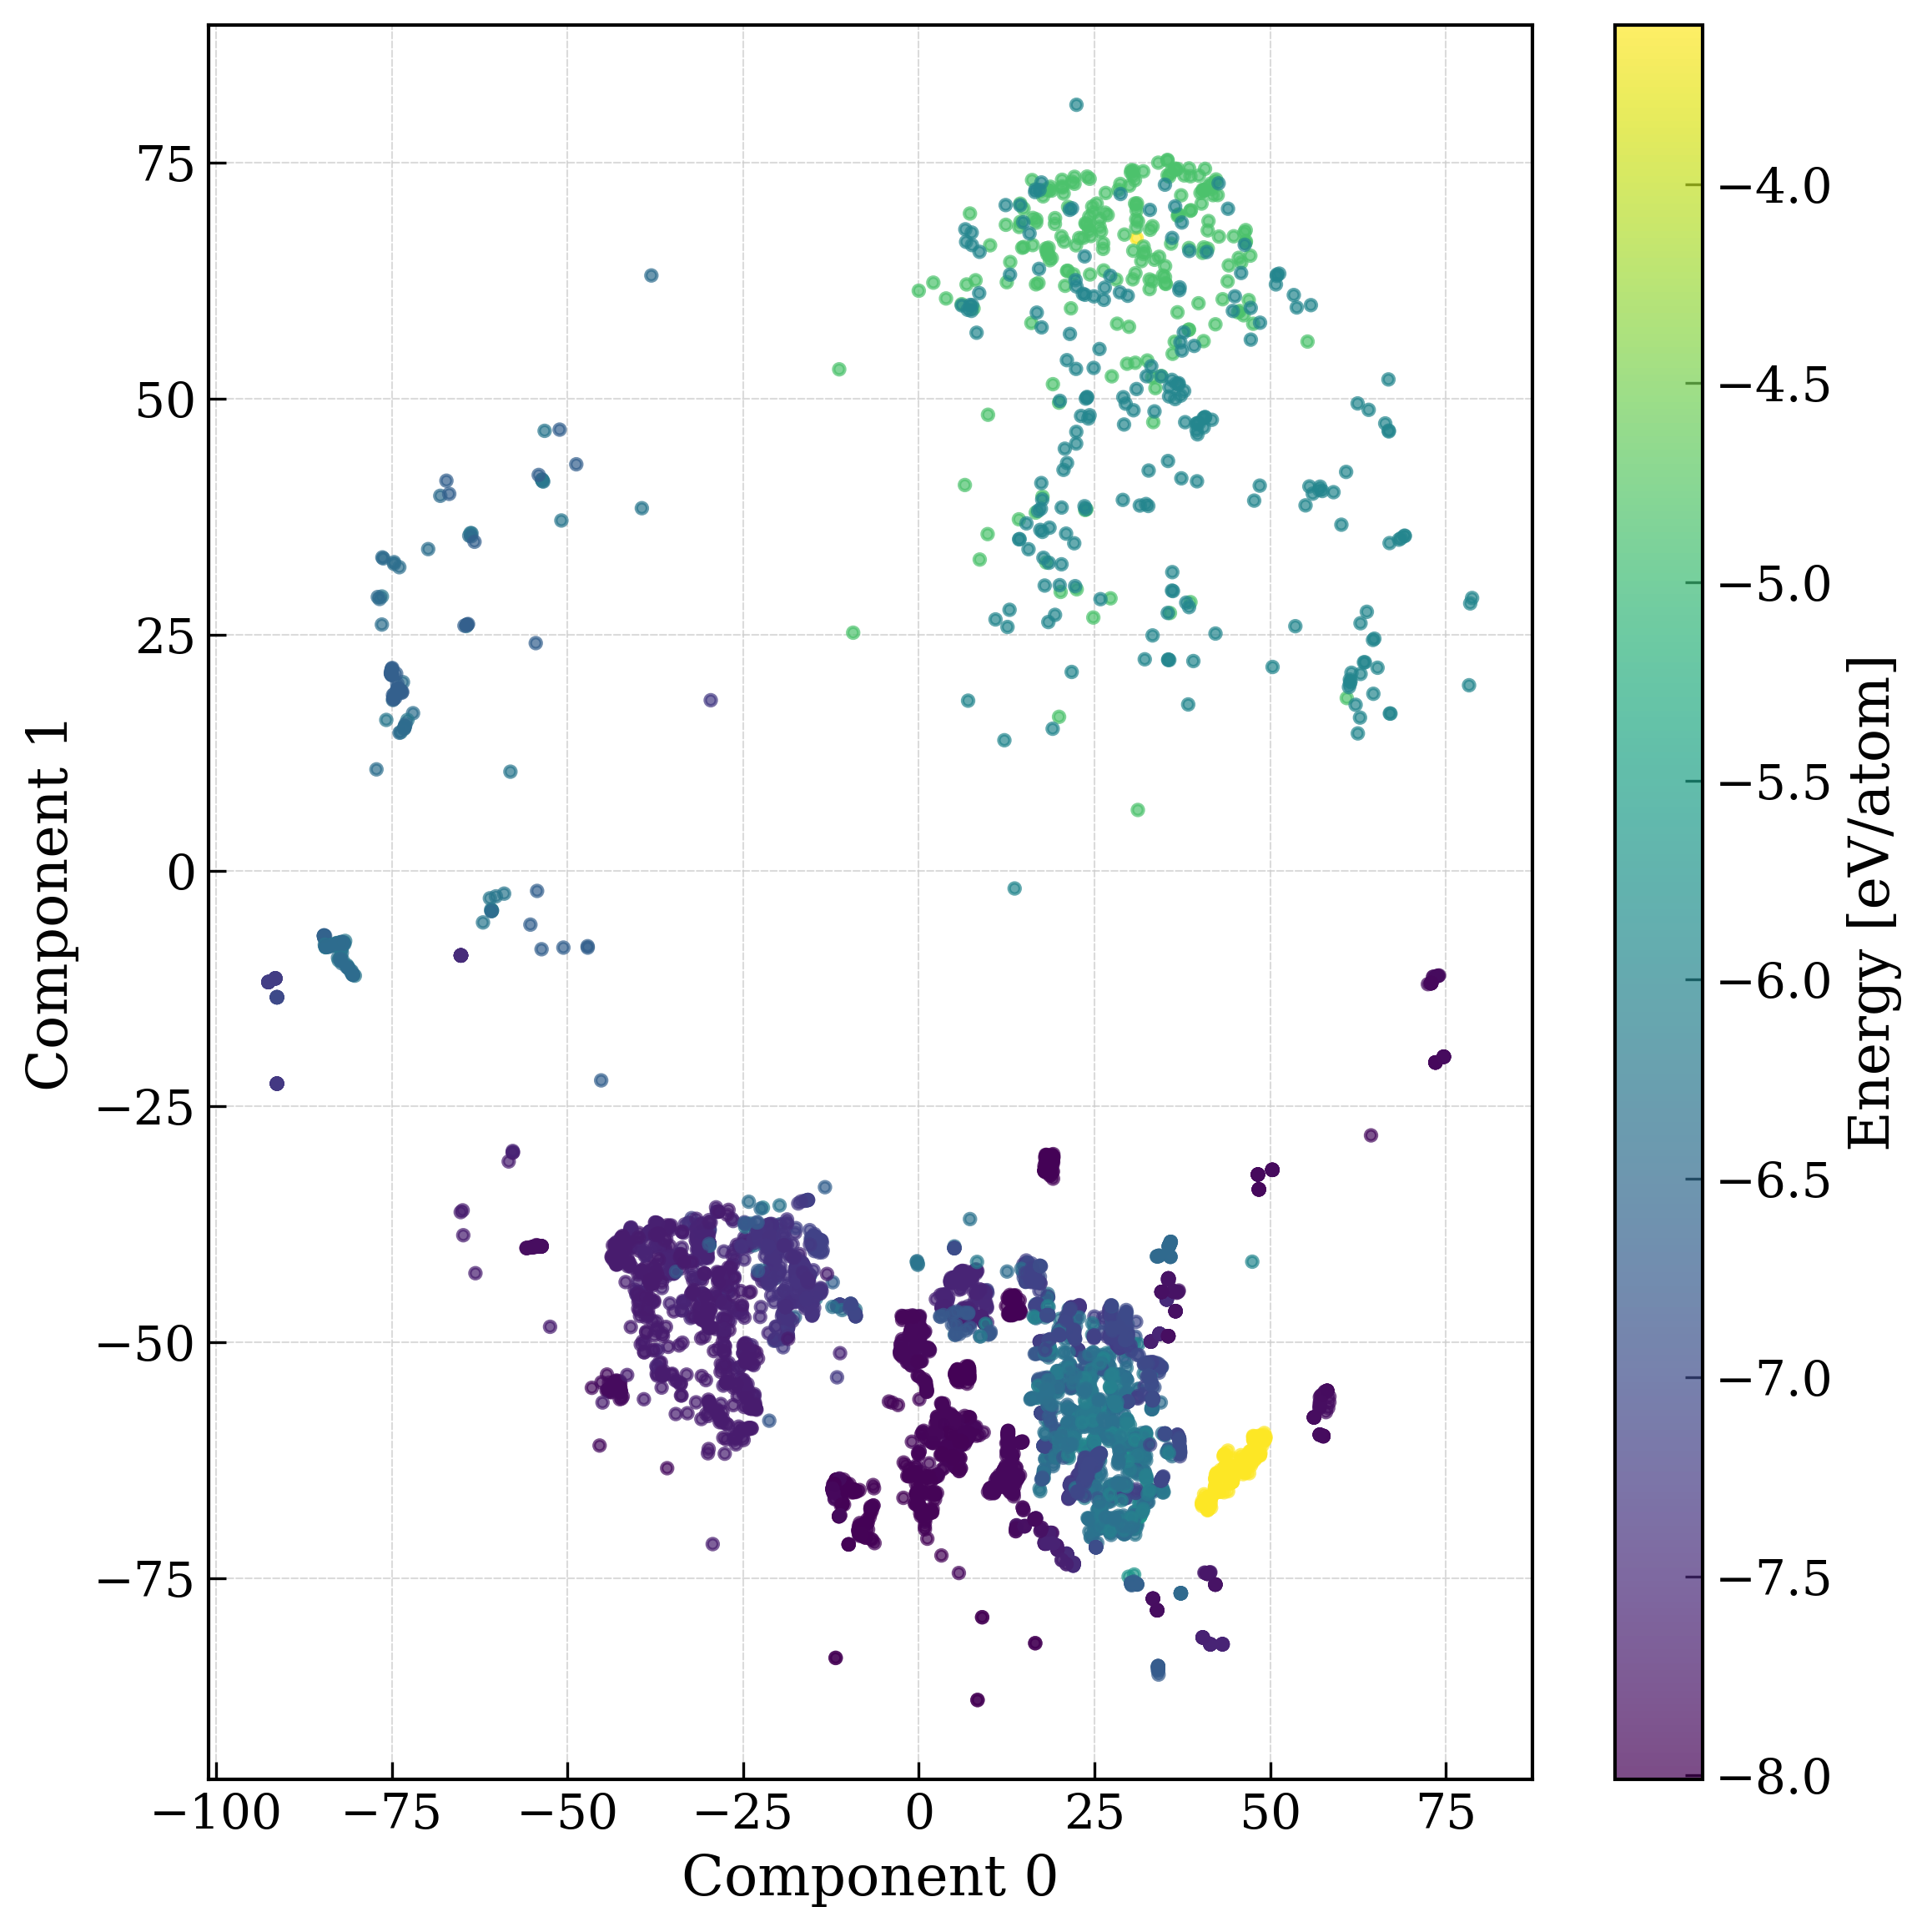

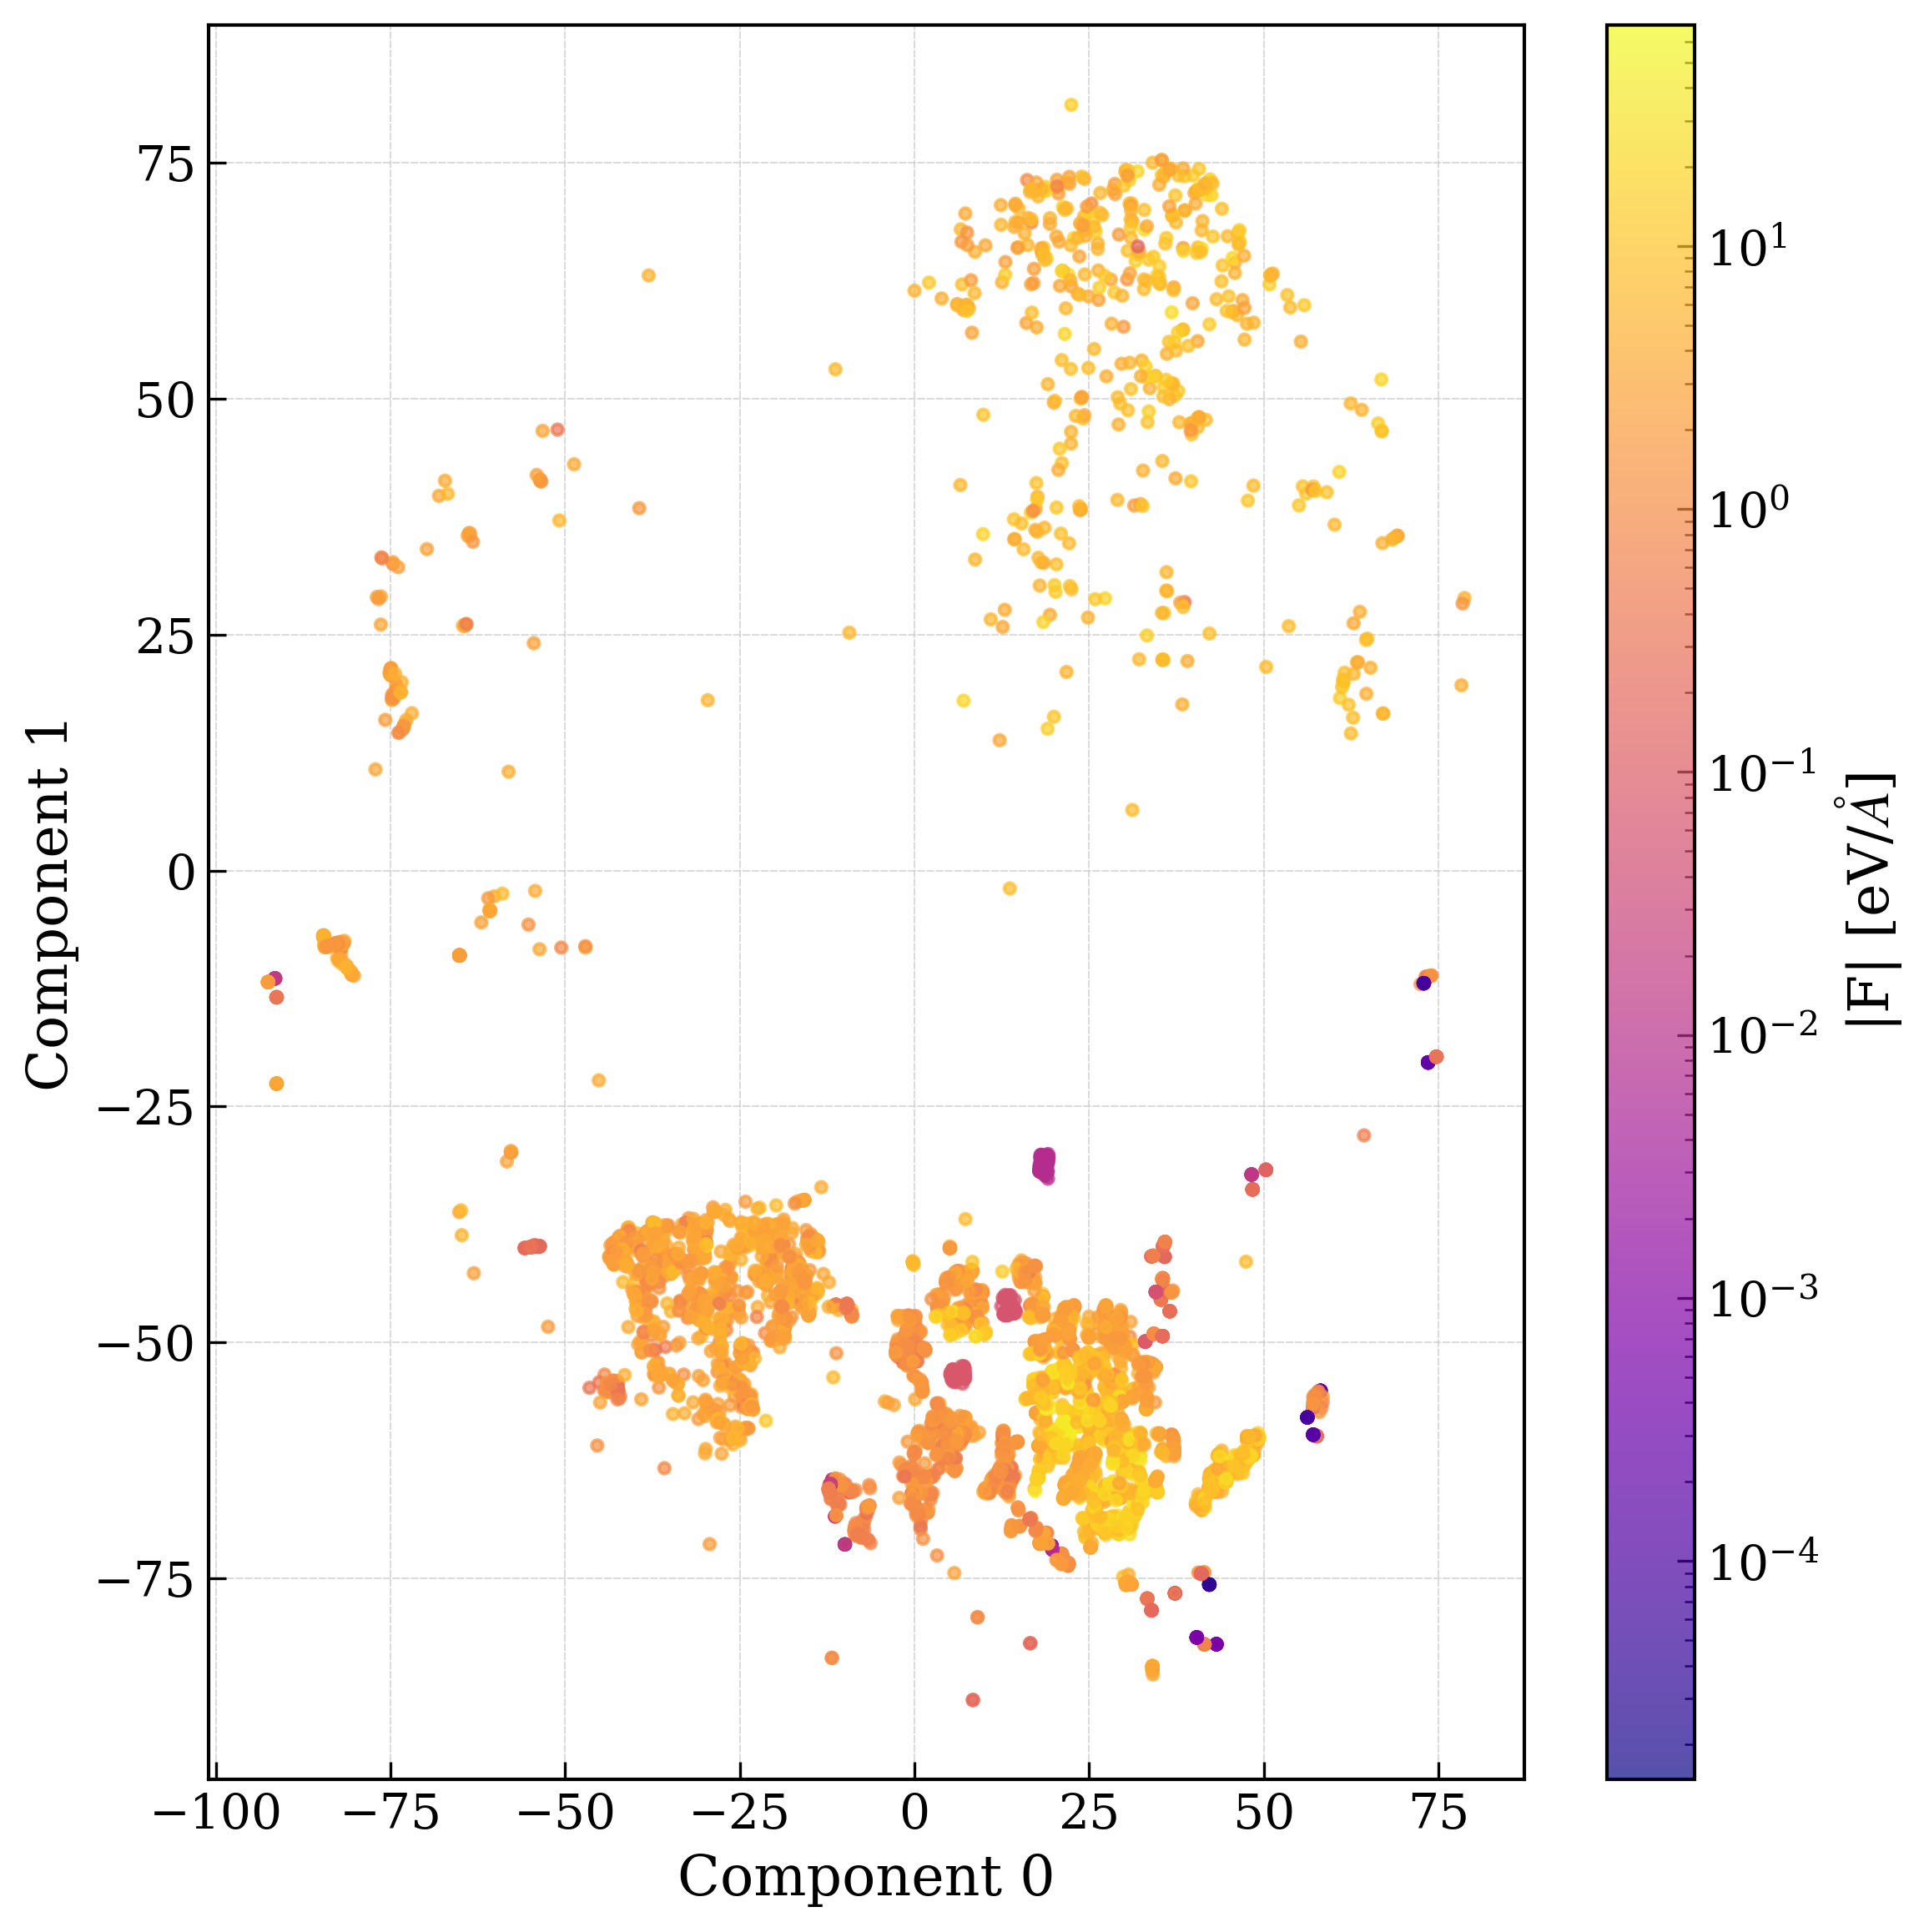

In [9]:
plot(tsne_results_val, energies_val, forces_val, config_type_val, target_config_types=["Nanotubes", "Graphite", "Fullerenes", "Liquid", "Crystalline_Bulk", "Diamond"])

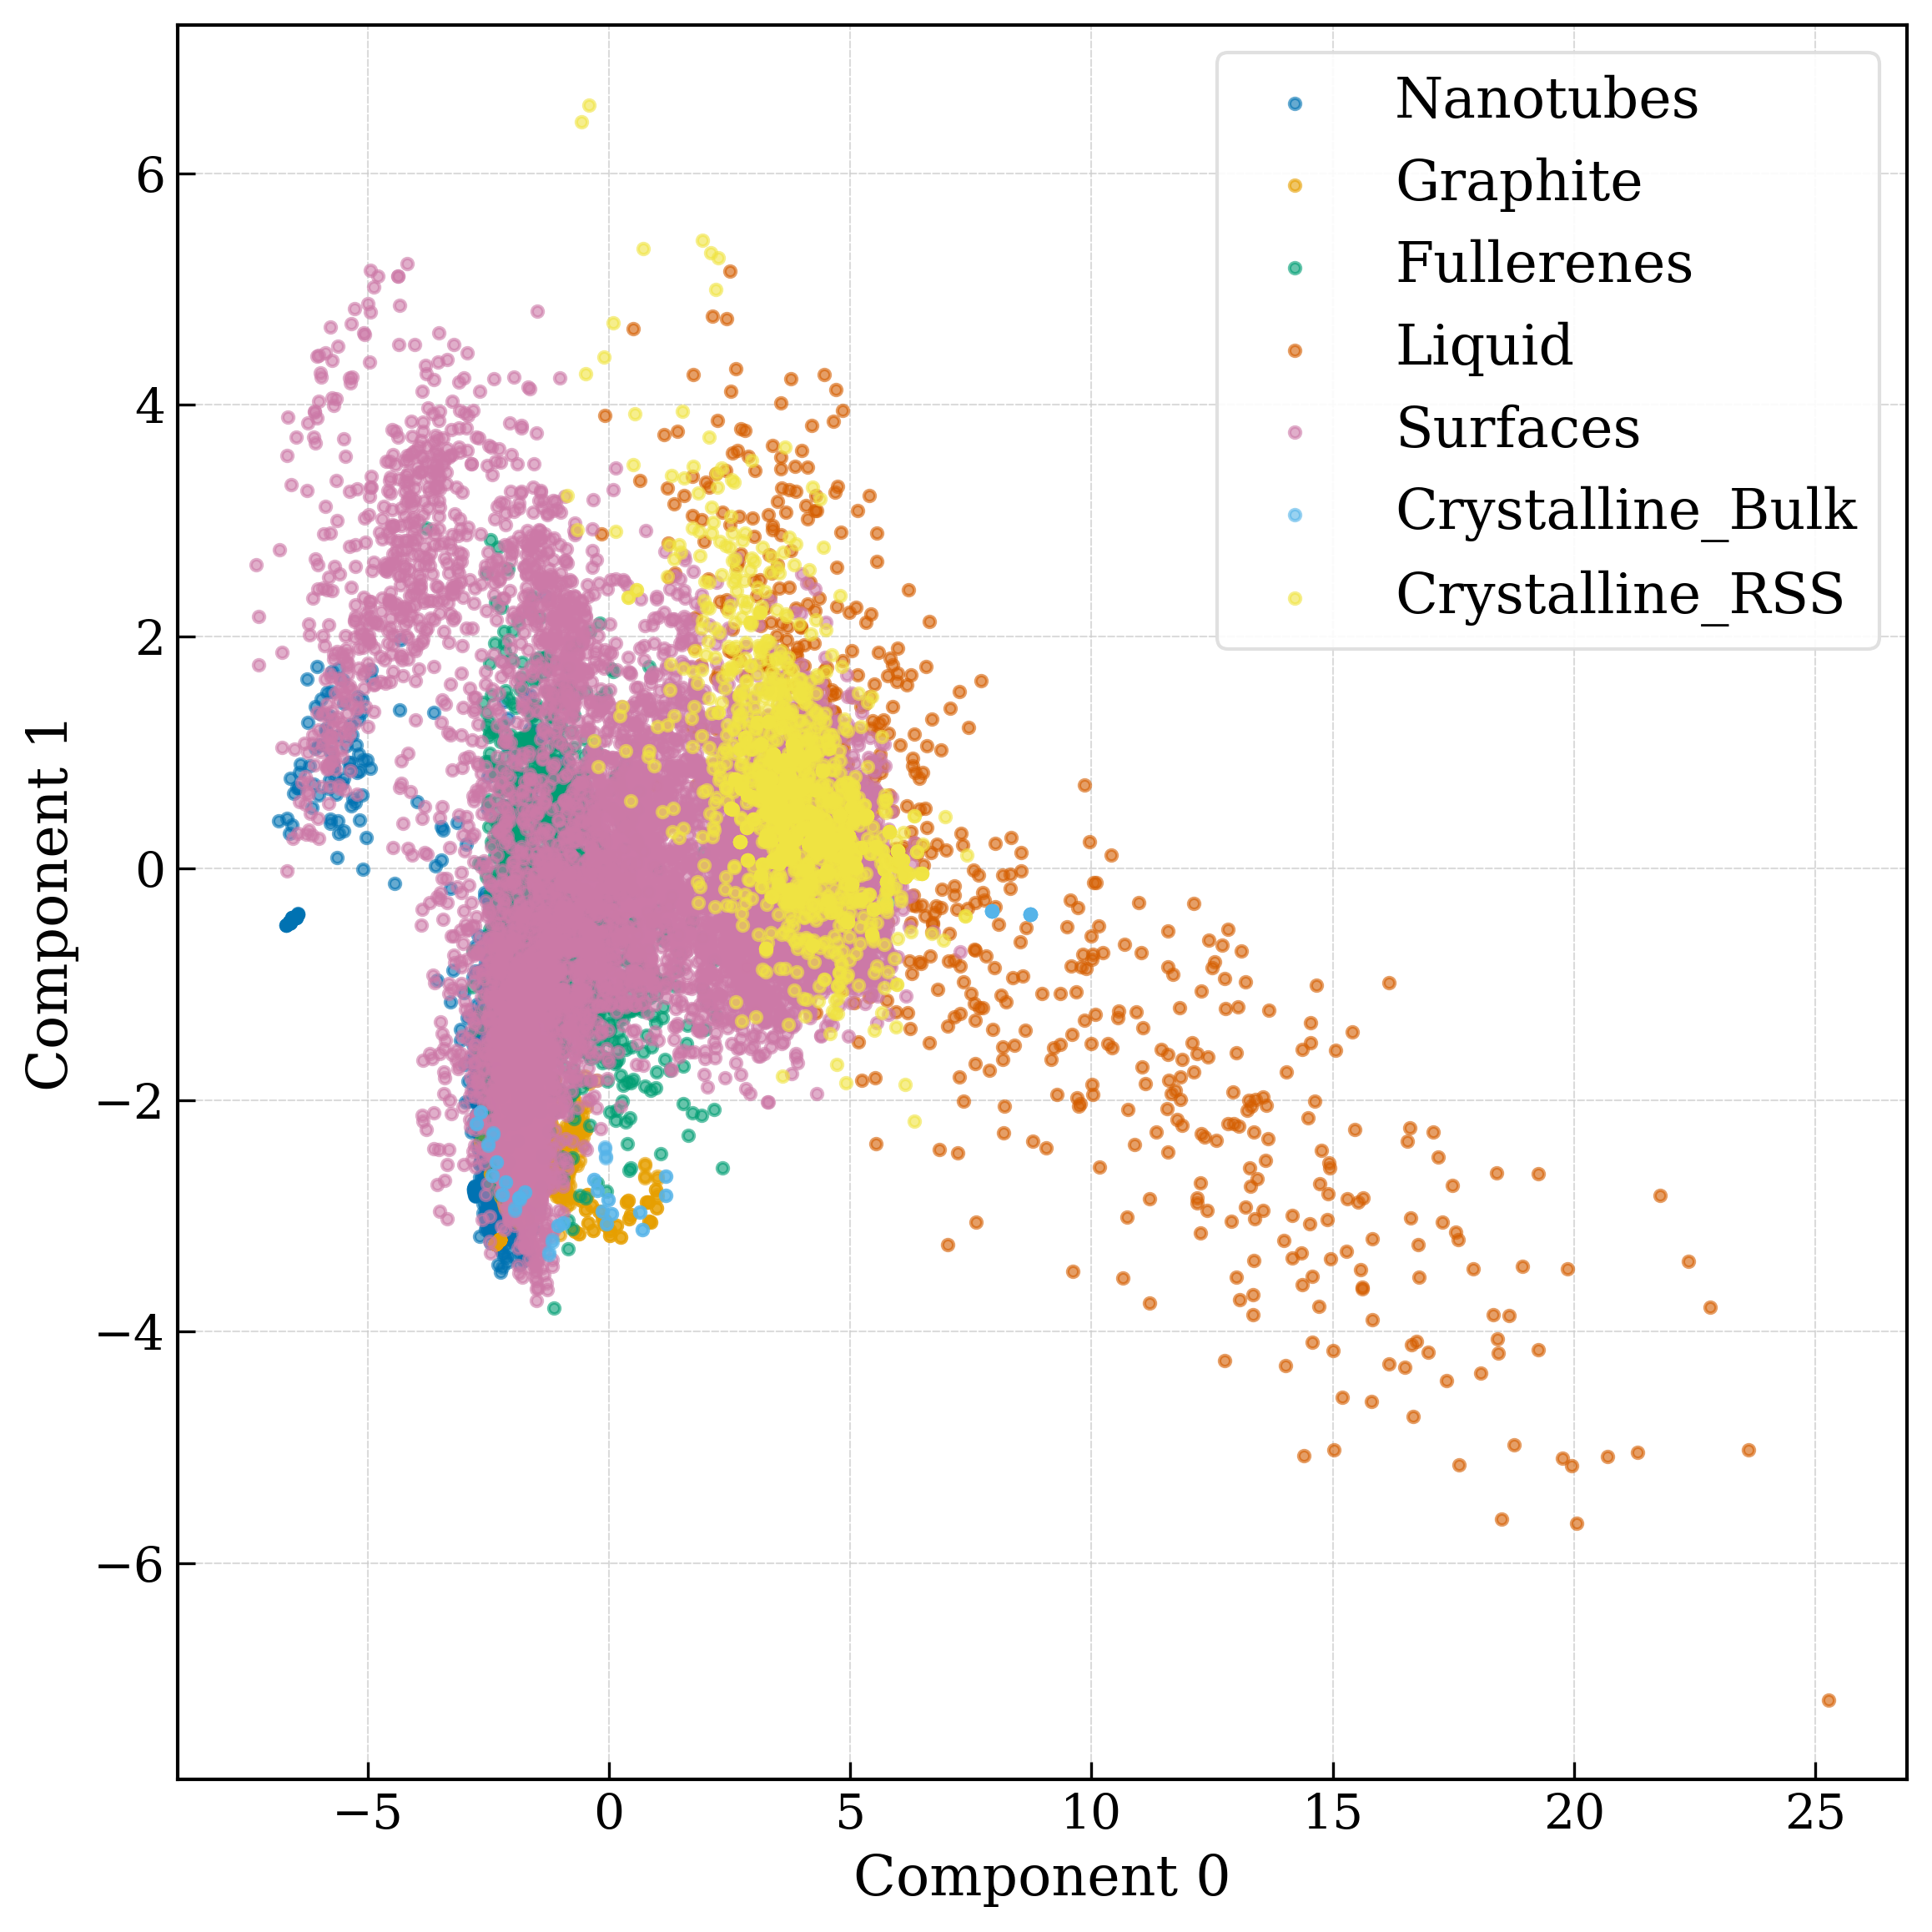

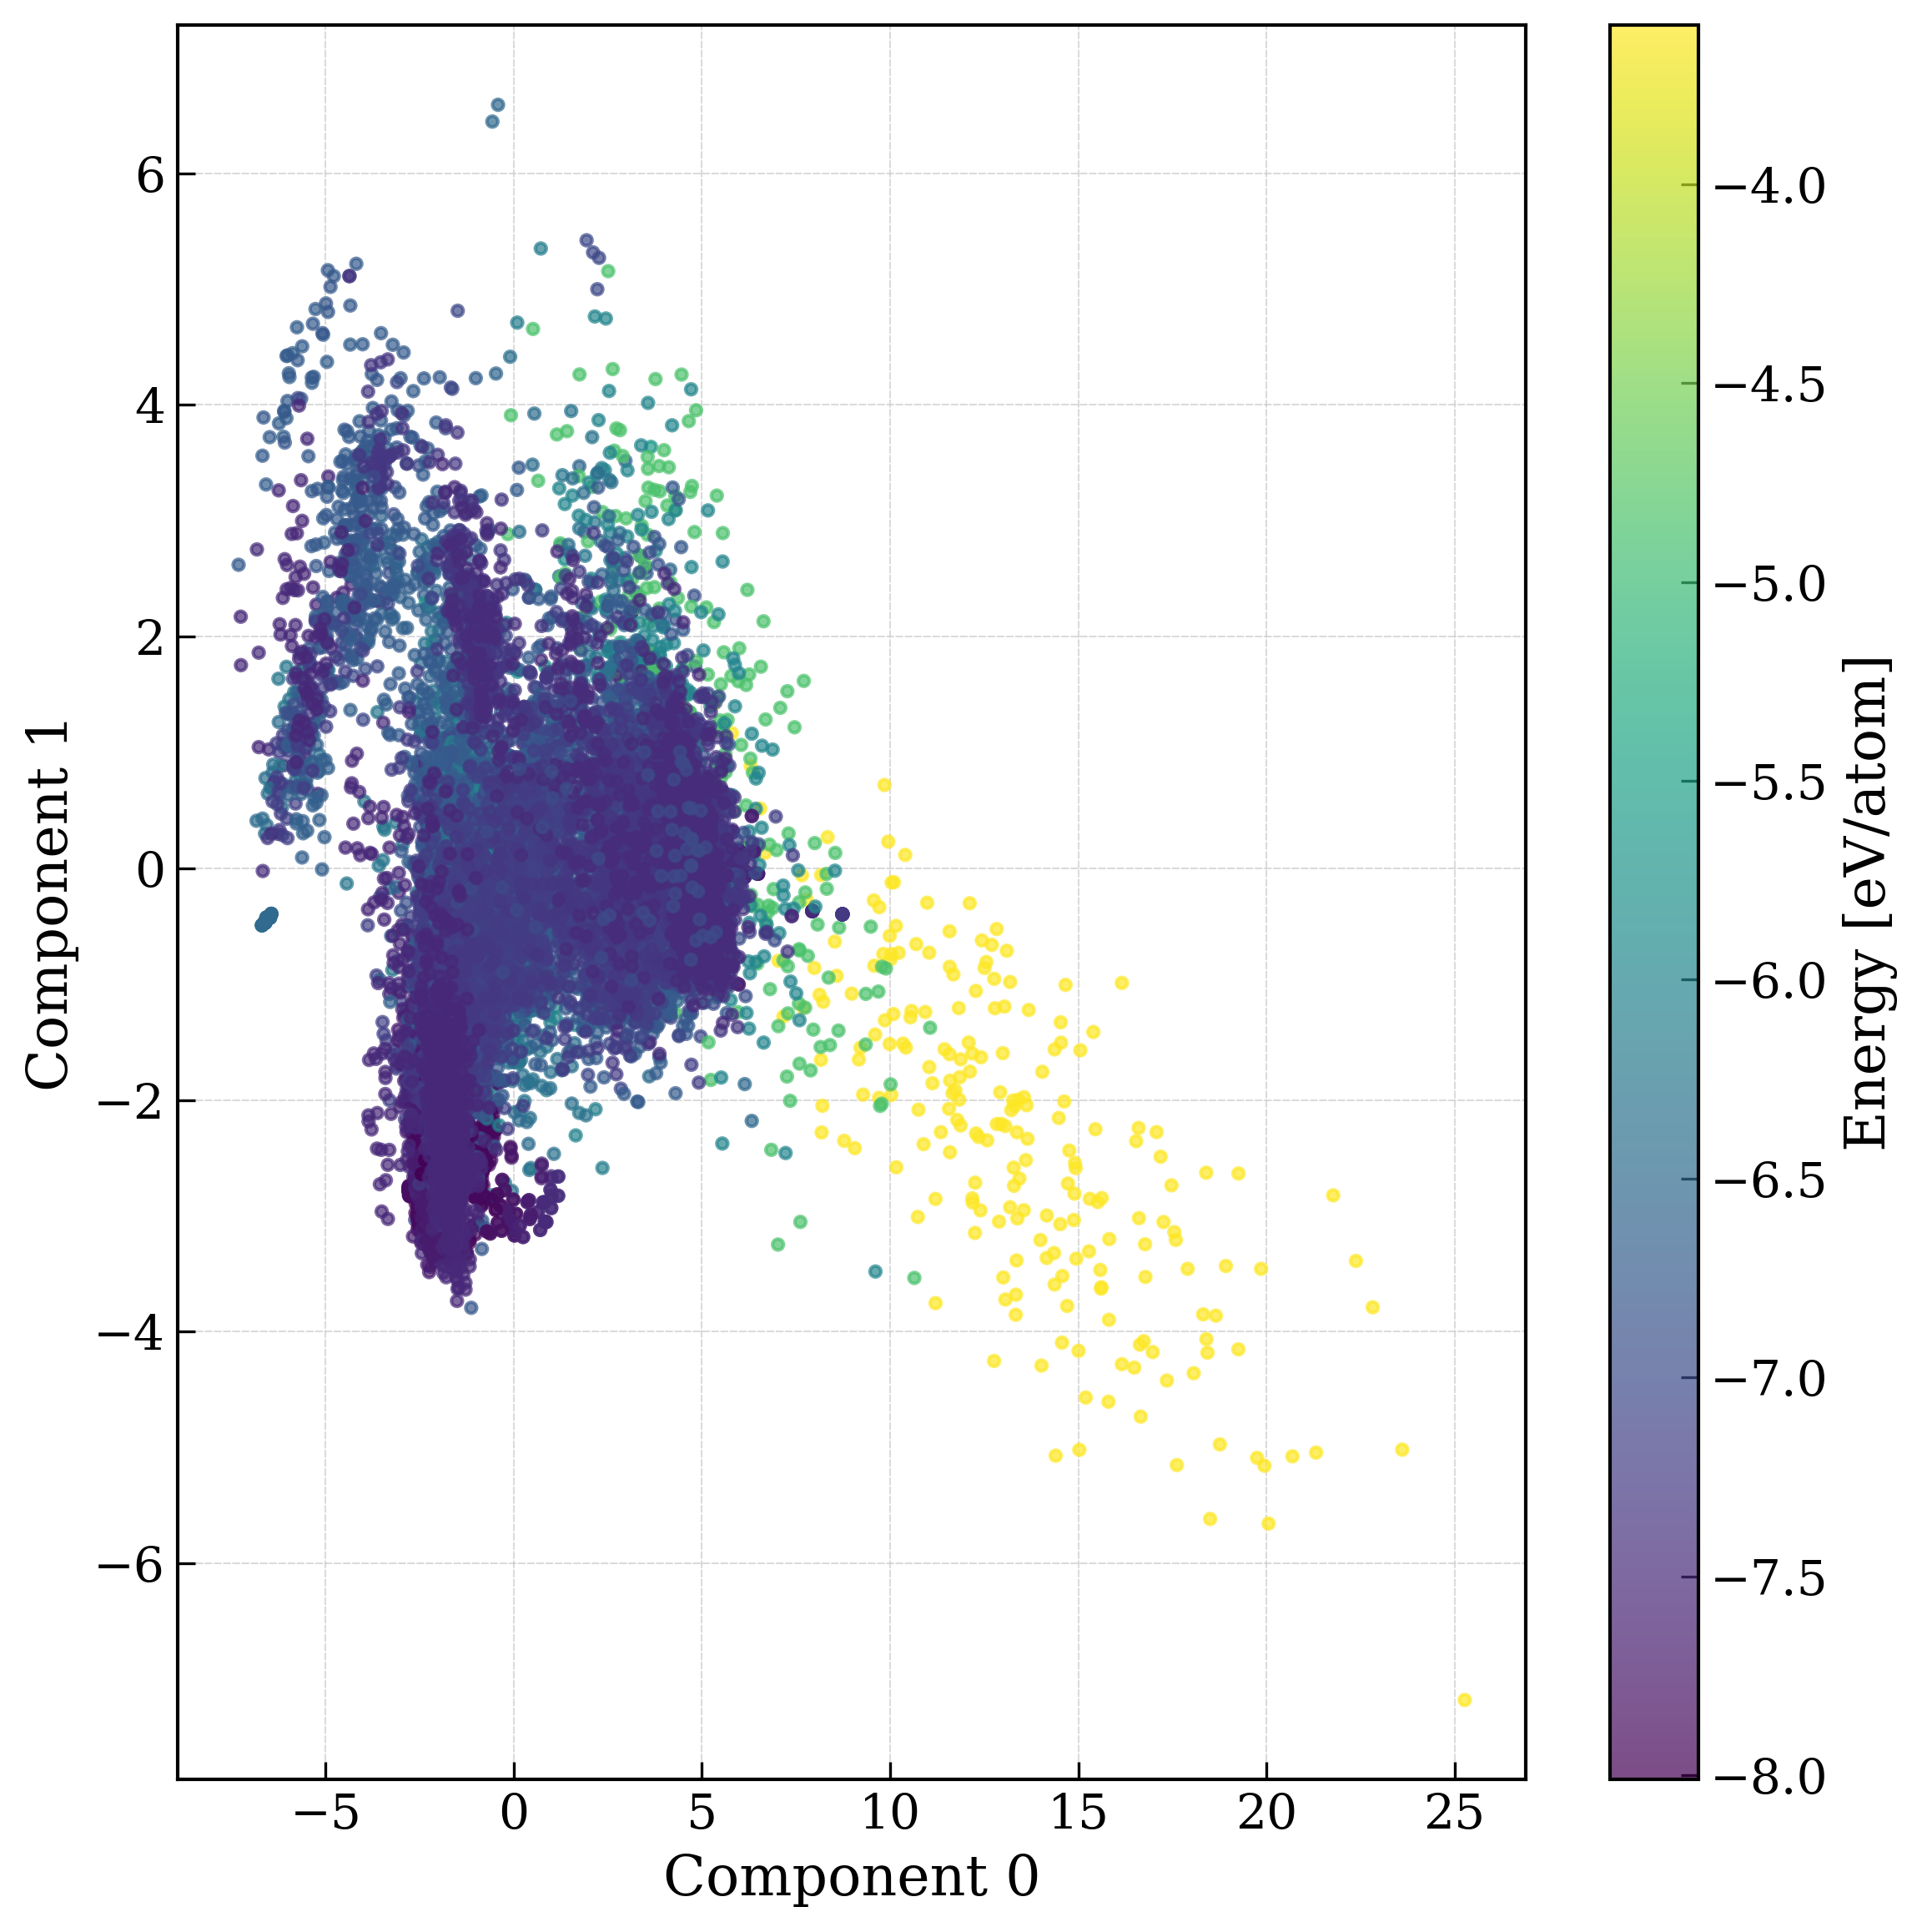

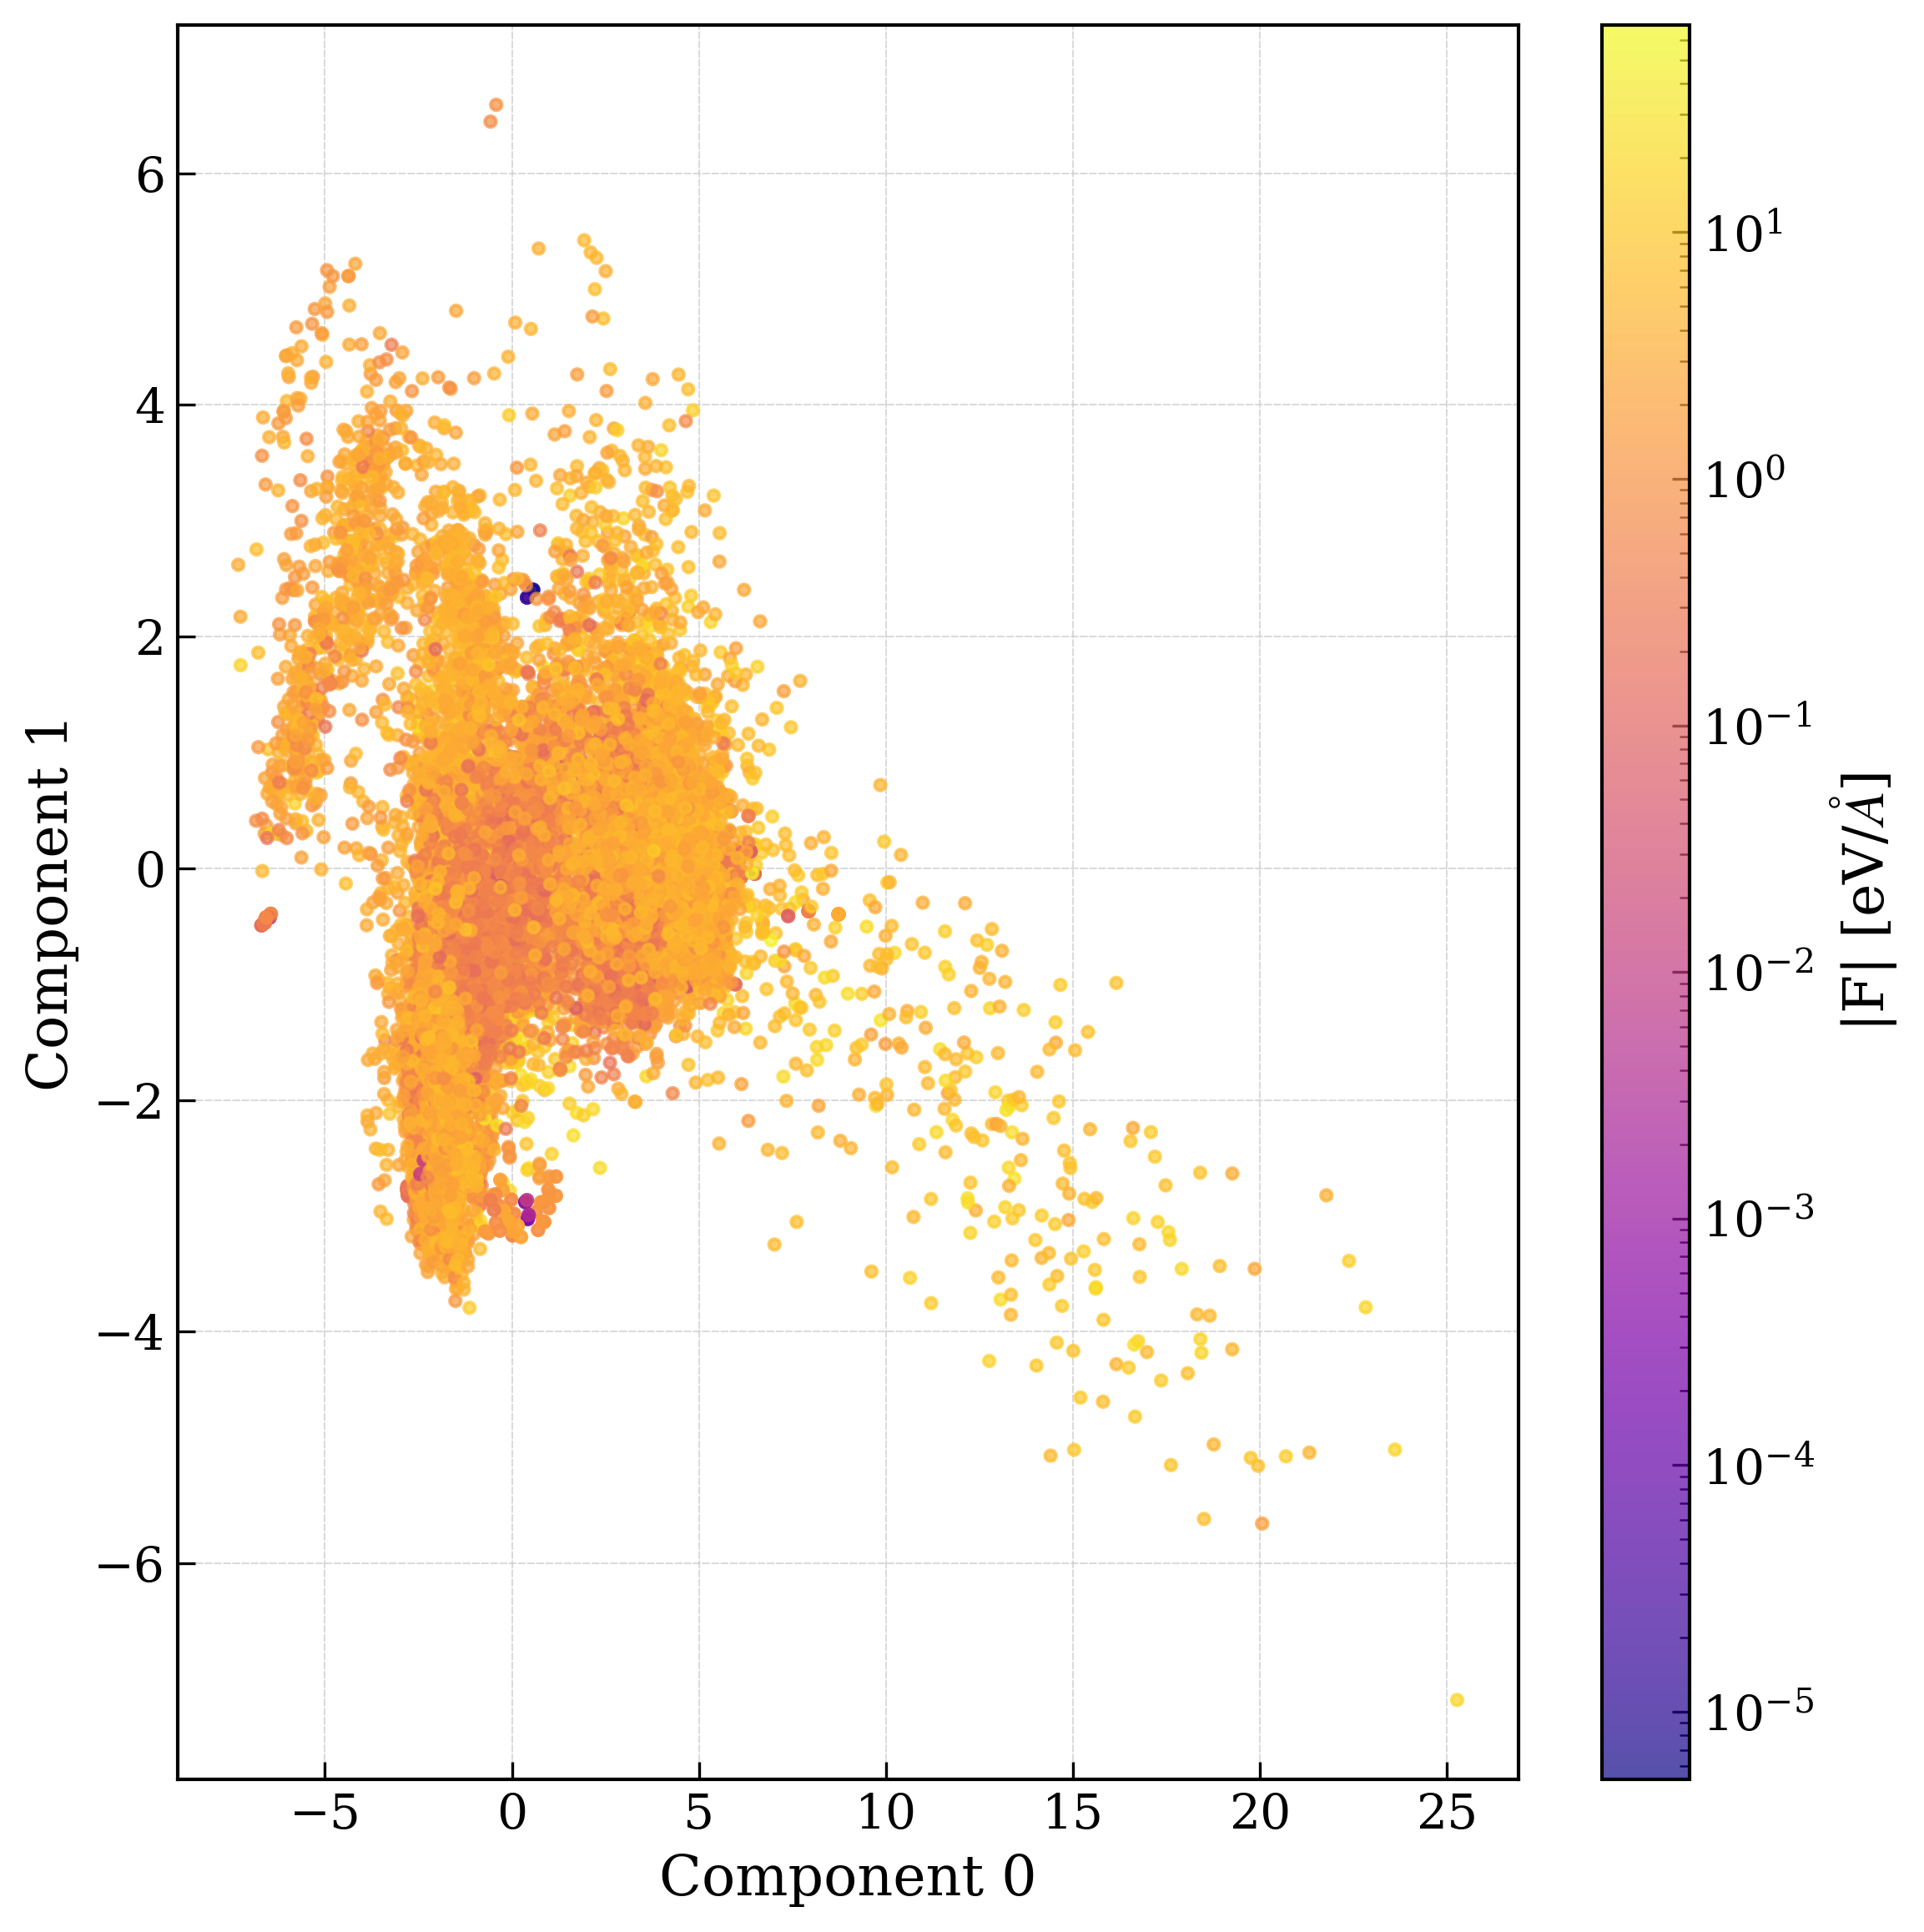

In [10]:
plot(pca_results, energies_val, forces_val, config_type_val, target_config_types=["Nanotubes", "Graphite", "Fullerenes", "Liquid", "Surfaces", "Crystalline_Bulk", "Crystalline_RSS"], i1=0, i2=1)

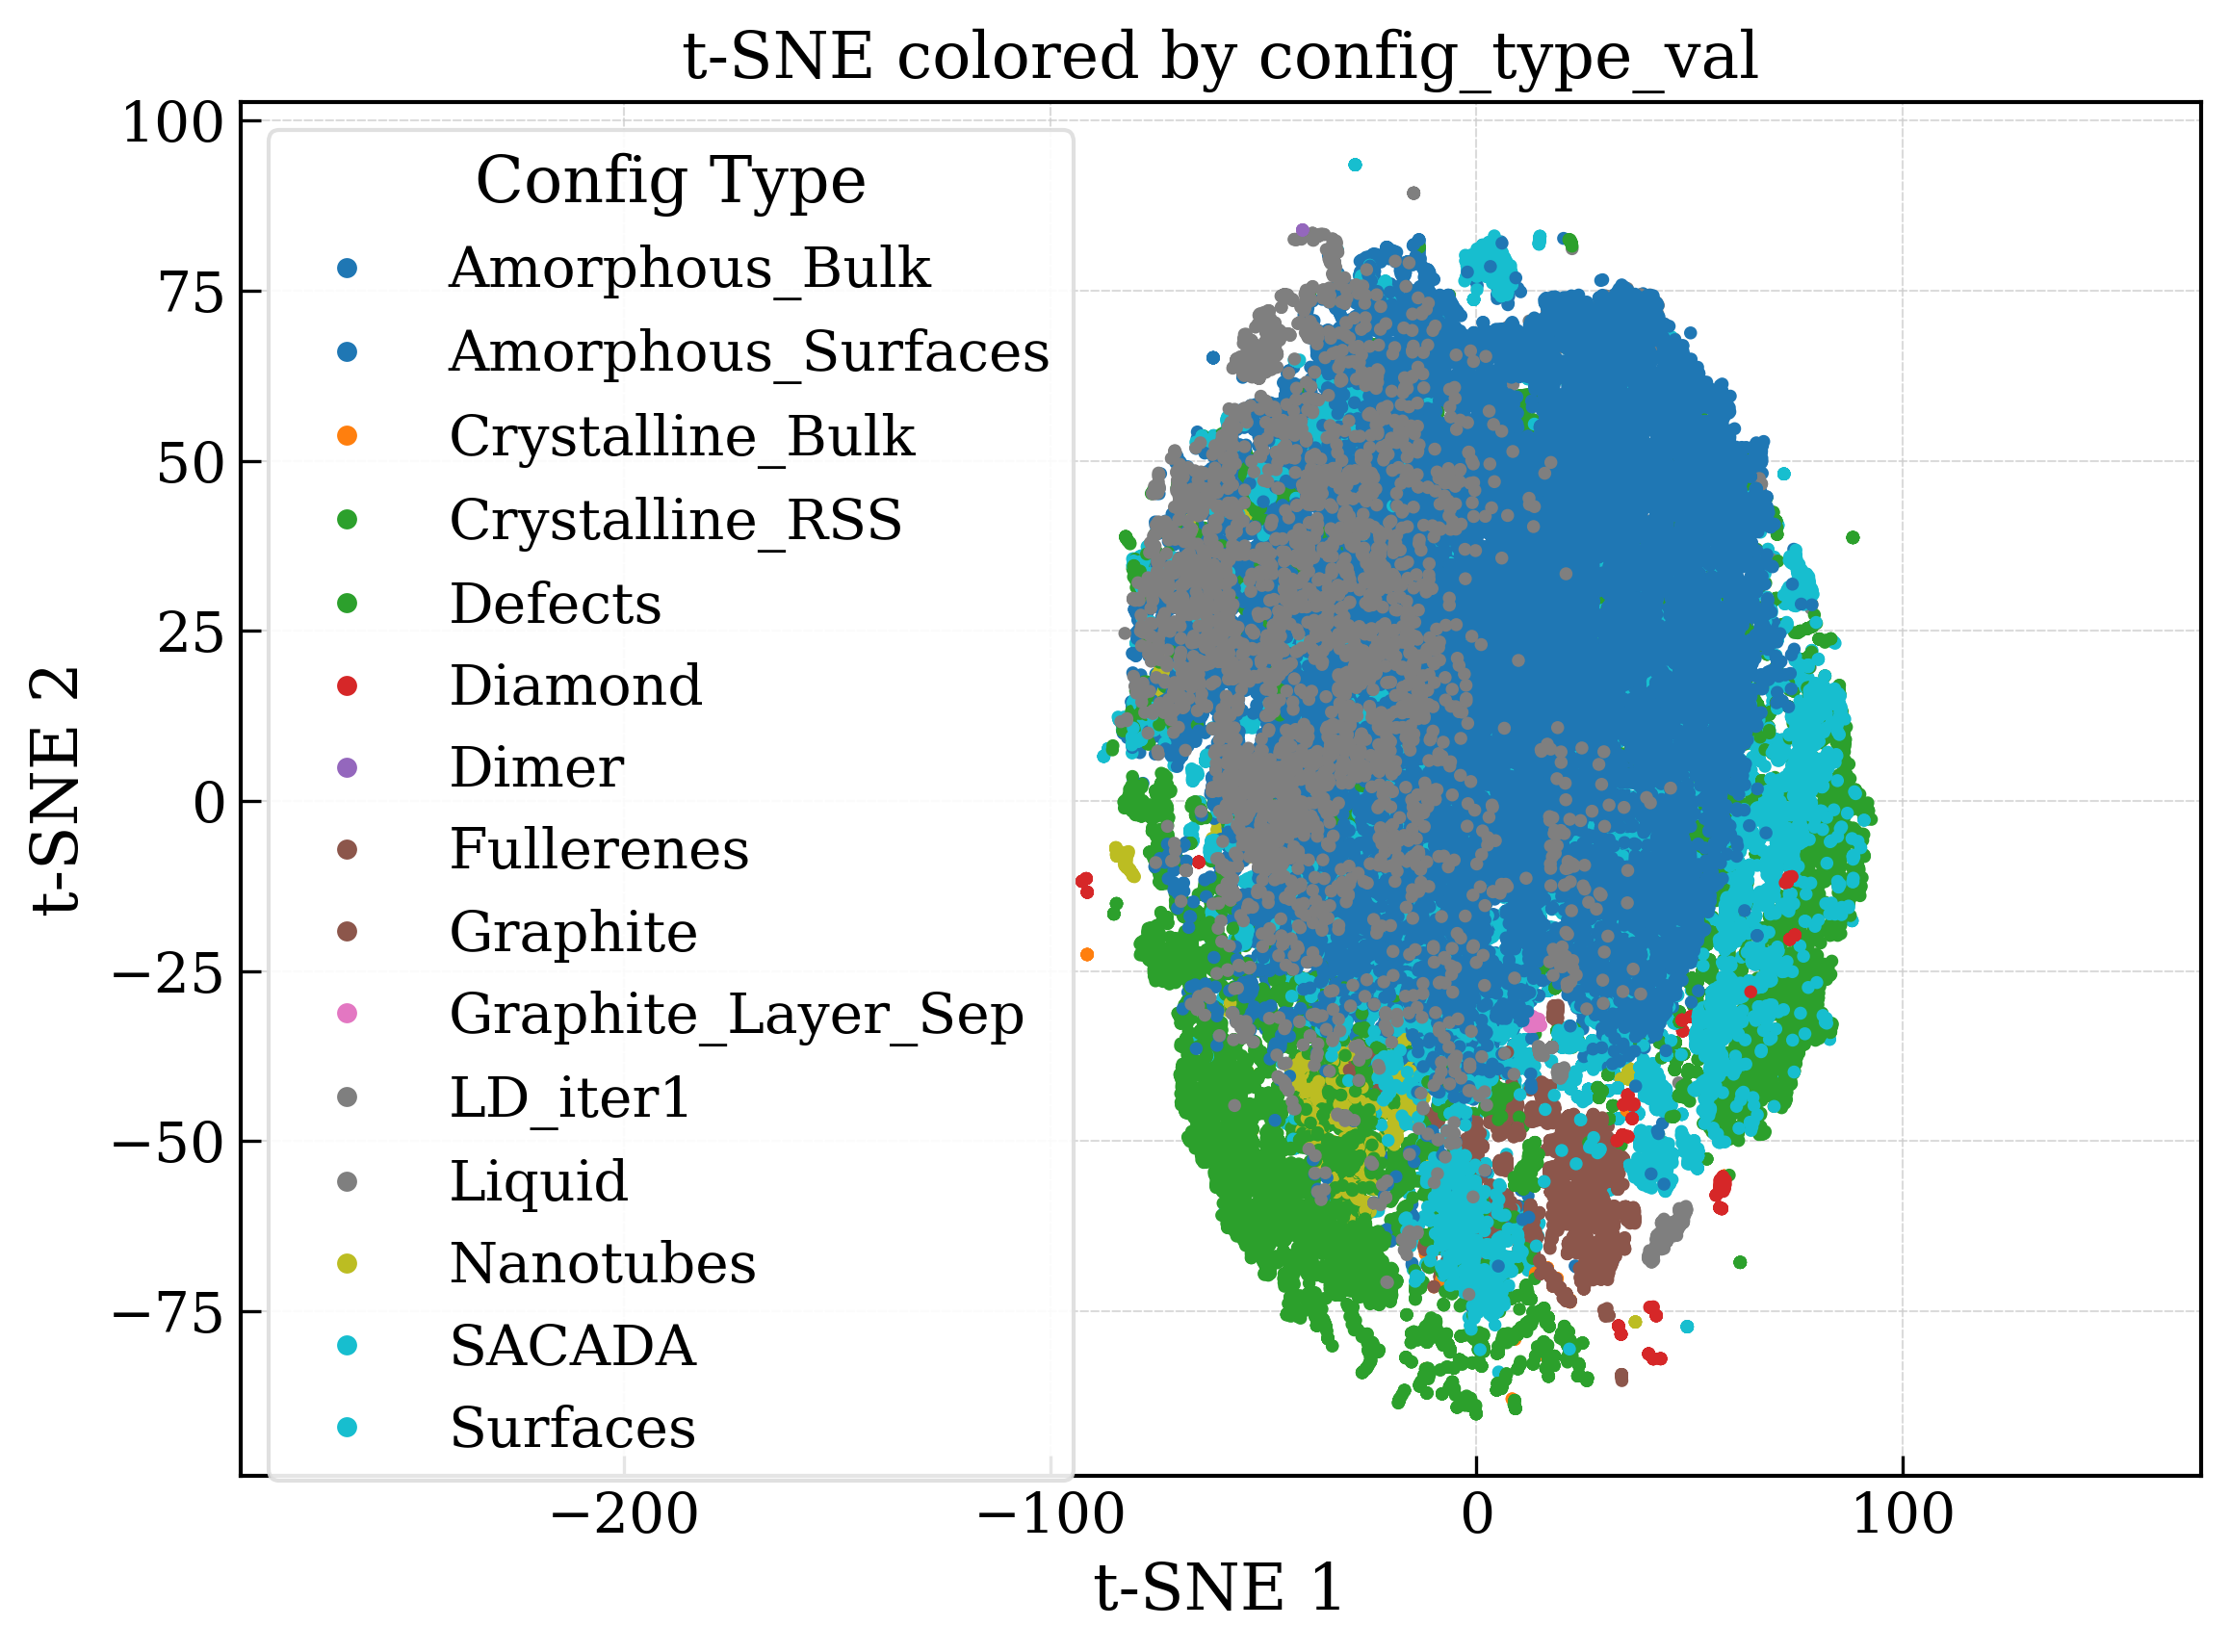

In [11]:
import matplotlib.pyplot as plt

categories = np.unique(config_type_val)  # get unique categories
colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))  # pick a qualitative colormap

# Create a mapping from category to color
color_map = {cat: colors[i] for i, cat in enumerate(categories)}

# Map your labels to colors
point_colors = [color_map[label] for label in config_type_val]

# Scatter plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(tsne_results_val[:, 0], tsne_results_val[:, 1],
                      c=point_colors, s=5)

# Create a legend
handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color_map[cat], markersize=6)
           for cat in categories]
plt.xlim(-290, 170)
plt.legend(handles, categories, title="Config Type", fontsize=14, loc="upper left")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE colored by config_type_val")
plt.show()

## UMAP

In [12]:
from umap import UMAP
from itertools import product

ModuleNotFoundError: No module named 'umap'

In [ ]:
nneighbours = 90
umap=UMAP(n_neighbors=nneighbours, n_components=2, random_state=42, init="random", metric="cosine")
embedding_umap = umap.fit(pca_results)

/home/gabri/anaconda3/envs/chemiscope/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/gabri/anaconda3/envs/chemiscope/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


: 

: 

In [ ]:
def plot_umap(umap_input, energies, forces, config_types, target_config_types=None, i1=0, i2=1):
    """
    Plot UMAP embeddings colored by configuration type, energy, and force magnitude.

    Args:
        umap_input: Either a fitted UMAP object or a precomputed embedding array (n_samples, n_components)
        energies (np.ndarray or list): Energy per atom/config
        forces (np.ndarray): Forces per atom (n_samples, 3)
        config_types (list): Configuration type per atom/config
        target_config_types (set or list, optional): Subset of config_types to plot
        i1, i2 (int): Indices of UMAP components to plot
    """

    # ------------------------------
    # Convert UMAP object to embedding if needed
    # ------------------------------
    if isinstance(umap_input, UMAP):
        # Assume you want to transform descriptors stored as 'descriptors' attribute
        if hasattr(umap_input, 'embedding_'):
            embedding = umap_input.embedding_  # already fitted
        else:
            raise ValueError("UMAP object is not fitted. Call fit_transform() first.")
    else:
        embedding = np.array(umap_input)

    if target_config_types is None:
        target_config_types = set(config_types)

    config_types = np.array(config_types)
    energies = np.array(energies)
    forces = np.array(forces)

    # compute force modulus
    force_mod = np.linalg.norm(forces, axis=1)

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # ----------------------------
    # 1. Plot by config_type
    # ----------------------------
    for config_type in target_config_types:
        mask = config_types == config_type
        axes[0].scatter(
            embedding[mask, i1],
            embedding[mask, i2],
            label=config_type,
            alpha=0.6,
            s=20
        )

    axes[0].set_title("Config Type", fontsize=14)
    axes[0].set_xlabel(f"UMAP Component {i1}")
    axes[0].set_ylabel(f"UMAP Component {i2}")
    axes[0].legend()
    axes[0].grid(True)

    # ----------------------------
    # 2. Plot by energy
    # ----------------------------
    target_mask = np.isin(config_types, target_config_types)
    sc1 = axes[1].scatter(
        embedding[target_mask, i1],
        embedding[target_mask, i2],
        c=energies[target_mask],
        cmap="viridis",
        s=20,
        alpha=0.7
    )

    axes[1].set_title("Energy")
    axes[1].set_xlabel(f"UMAP Component {i1}")
    axes[1].set_ylabel(f"UMAP Component {i2}")
    axes[1].grid(True)
    fig.colorbar(sc1, ax=axes[1], label="Energy")

    # ----------------------------
    # 3. Plot by force magnitude
    # ----------------------------
    sc2 = axes[2].scatter(
        embedding[target_mask, i1],
        embedding[target_mask, i2],
        c=force_mod[target_mask],
        cmap="plasma",
        s=20,
        alpha=0.7
    )

    axes[2].set_title("Force Magnitude")
    axes[2].set_xlabel(f"UMAP Component {i1}")
    axes[2].set_ylabel(f"UMAP Component {i2}")
    axes[2].grid(True)
    fig.colorbar(sc2, ax=axes[2], label="|F|")

    plt.tight_layout()
    plt.show()

: 

: 

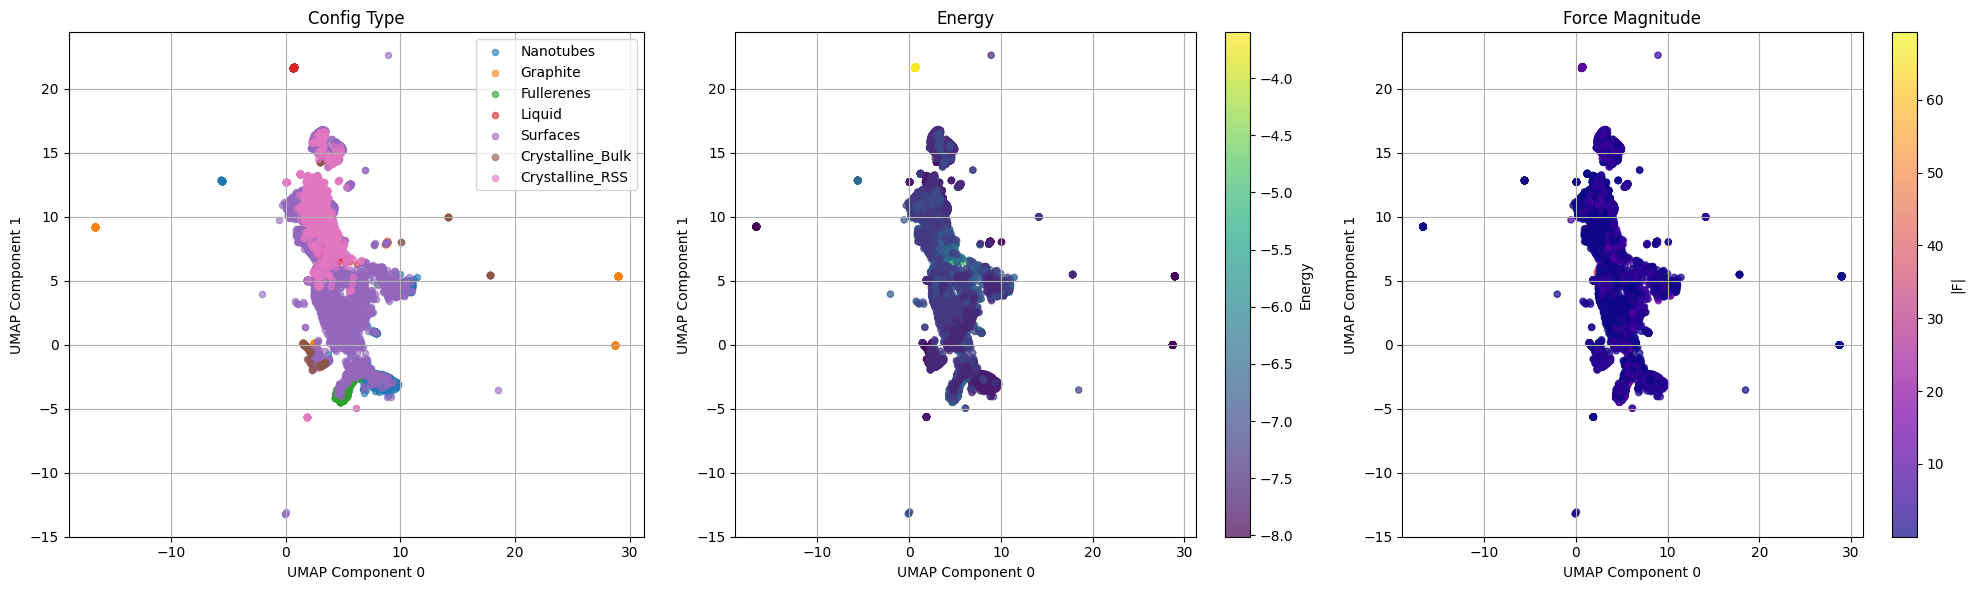

: 

: 

In [ ]:
plot_umap(embedding_umap, energies_val, forces_val, config_type_val, target_config_types=["Nanotubes", "Graphite", "Fullerenes", "Liquid", "Surfaces", "Crystalline_Bulk", "Crystalline_RSS"], i1=0, i2=1)